Below, we have imported the Python libraries needed for this module. Run the code in this cell before running any other code cells, and be careful **not to change** any of the code.
You can run the cell in any of these ways:
 - Ctrl + Enter: Run the cell and keep the cursor in the same cell.
- Shift + Enter: Run the cell and move the cursor to the next cell.
- Click the Play button: Click the Run (play) button to the left of the cell to execute it.

In [1]:
# Necessary imports for this module
from utils import *

# Sampling Distributions & Central Limit Theorem

**Estimated Time**: 30 Minutes <br>
**Professor**: Alice Martinez <br>
**Developers**: James Geronimo, Mark Barranda, Rinrada Maneenop

**The sampling distribution of a statistic** is the distribution of all values of a statistic when all possible samples of the same size *n* are taken from the same population.

The basic idea is this: If you were to take multiple samples, what values from those samples will give you the best estimates of the population values?

---

## Example 1: Fair Die

In [2]:
n_samples = 10000
sample_size = 5
population = np.arange(1, 7)

### Means

**Sampling Procedure:**  
Roll a fair six-sided die 5 times and record the sample mean, $\bar{x}$. <br>
Repeat this process 10,000 times to build a **distribution of sample means**.

- **Population Mean ($\mu$):** 3.5

🟩 The dashed green line represents the **mean of all sample means**.

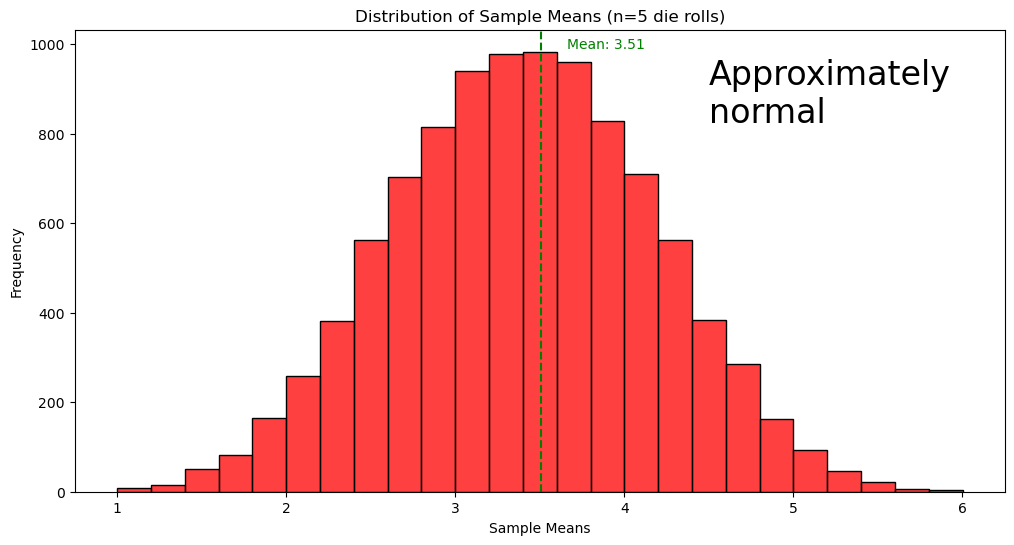

In [3]:
fair_die_means(n_samples, sample_size, population)

In this cell block, we show a few indivudal sample means generate from five samples.

In [4]:
for i in range(5):
    rolls = np.random.choice(population, size=sample_size)
    print(f"Sample {i+1} rolls: {rolls}, Sample Mean: {np.mean(rolls):.2f}")

Sample 1 rolls: [4 1 4 2 5], Sample Mean: 3.20
Sample 2 rolls: [6 3 1 1 6], Sample Mean: 3.40
Sample 3 rolls: [3 4 3 5 2], Sample Mean: 3.40
Sample 4 rolls: [3 3 2 6 1], Sample Mean: 3.00
Sample 5 rolls: [6 5 6 3 3], Sample Mean: 4.60


All outcomes are equally likely so the **population** mean is 3.5.

The **mean** of the sample means in 10,000 trials is 3.51. If continued indefinitely, the sample mean will be 3.5.

**Note:**
1) The mean of the sample means **equals** the value of the population mean
2) The sample means have a **approximately normal** distribution

### Variances

**Sampling Procedure:**  
Roll a fair six-sided die 5 times and record the sample variance, $s^2$. <br>
Repeat this process 10,000 times to build a **distribution of sample variances**.

- **Population Variance ($\sigma^2$):** 2.9

🟩 The dashed green line represents the **mean of all sample variances**.

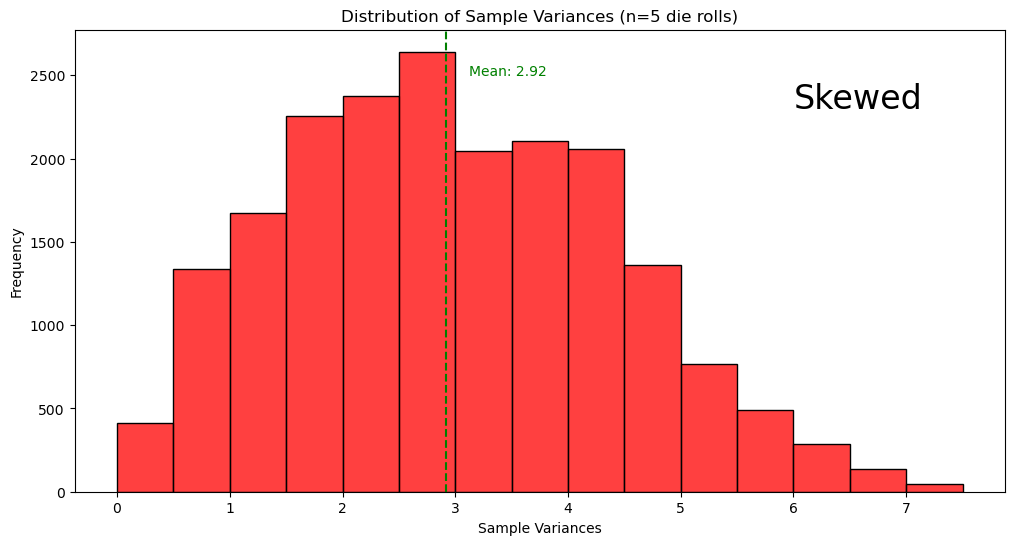

In [5]:
fair_die_variances(n_samples, sample_size, population)

In this cell block, we show a few individual sample variances generate from five samples.

In [6]:
for i in range(5):
    rolls = np.random.choice(population, size=sample_size)
    print(f"Sample {i+1} rolls: {rolls}, Sample Mean: {np.var(rolls, ddof=1):.2f}")

Sample 1 rolls: [4 3 4 1 3], Sample Mean: 1.50
Sample 2 rolls: [1 4 4 2 6], Sample Mean: 3.80
Sample 3 rolls: [1 1 5 5 5], Sample Mean: 4.80
Sample 4 rolls: [5 1 2 5 1], Sample Mean: 4.20
Sample 5 rolls: [2 2 5 1 3], Sample Mean: 2.30


All outcomes are equally likely so the **population** variance is 2.9.

The **mean** of sample variance in the 10,000 trials is 2.92. If continued indefinitely, the sample variance will be 2.9.

**Note:**
1) The mean of the sample variances **equals** the value of the population variance
2) The sample variances have a **skewed** distribution

### Proportions

**Sampling Procedure:**  
Roll a fair six-sided die 5 times and record the proportion of odd numbers. <br>
Repeat this process 10,000 times to build a **distribution of odd number proportions**.

- **Population Proportion of Odd Numbers ($p$):** 0.5
- $\hat{p}$ represents the sample proportion of odd numbers

🟩 The dashed green line represents the **mean of all odd number proportions**.

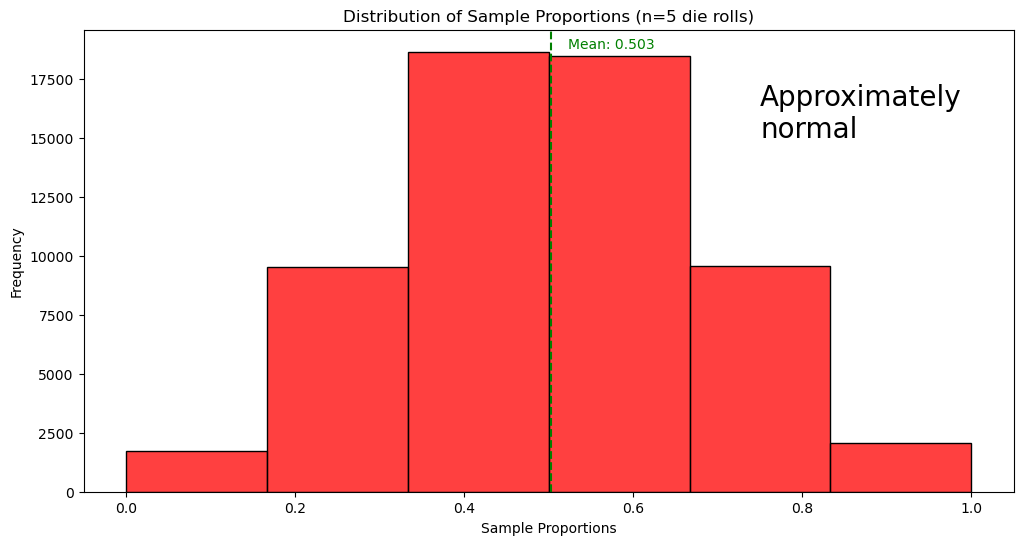

In [7]:
fair_die_proportions(n_samples, sample_size, population)

In this cell block, we show a few indivudal sample proportions generate from five samples.

In [8]:
for i in range(5):
    rolls = np.random.choice(population, size=sample_size)
    print(f"Sample {i+1} rolls: {rolls}, Sample Mean: {np.sum(rolls % 2 == 1) / sample_size:.2f}")

Sample 1 rolls: [3 6 6 3 5], Sample Mean: 0.60
Sample 2 rolls: [4 6 4 1 3], Sample Mean: 0.40
Sample 3 rolls: [3 4 6 1 2], Sample Mean: 0.40
Sample 4 rolls: [3 5 4 1 3], Sample Mean: 0.80
Sample 5 rolls: [6 1 5 1 4], Sample Mean: 0.60


All outcomes are equally likely so the **population proportion** of odd numbers is 0.5.

The mean of the **sample proportions** of the 10,000 trials is 0.503. If continued indefinitely, the mean of sample proportions will be 0.5.

**Note:**
1) The mean of the sample proportions **equals** the value of the population proportions
2) The sample proportions have a **approximately normal** distribution

### Estimators

Using the above information, we discover **biased** and **unbiased estimators** of population parameters.

#### Unbiased Estimators:

The **sample mean** $\bar{x}$, **sample variance** $s^2$, and **sample proportion** $\hat{p}$ of the samples are unbiased estimators of the corresponding population parameters $\mu$, $\sigma^2$, and $p$ because they target the value that the population would have.

#### Biased Estimators:

The **sample median**, **sample range**, and **sample standard deviation** $s$ do NOT target their corresponding population parameters, so they are generally NOT good estimators. However: often bias in the $s$ is small enough that it is used to estimate $\sigma$.

---

## Example 2: Assassinated Presidents

There are four U.S. presidents who were assassinated in office. Their ages (in years) were Lincoln 56, Garfield 49, McKinley 58, and Kennedy 46.

**a)** Assuming that 2 of the ages are randomly selected with replacement from [56, 49, 58, 46], list the 16 different possible samples by replacing the ellipses with appropriate values. We've filled out a few as a hint:

[56, 56]   [49, 56]   [58, 56]   [46, 56] <br>
[56, 49]   [49, 49]   [58, 49]   [46, 49] <br>
[56, 58]   [49, 58]   [58, 58]   [46, 58] <br>
[56, 46]   [49, 46]   [58, 46]   [46, 46]

**b)** Find the sample mean and range of possible samples by completing the functions `calculate_mean`, `calculate_range`, and `calculate_probability`. Then, run the cell to create tables that represent the probability distribution of each statistic.

In [9]:
def calculate_mean(number1, number2):
    """Calculate the mean of two numbers."""
    return (number1 + number2) / 2
    
def calculate_range(number1, number2):
    """Calculate the range of two numbers."""
    return max(number1, number2) - min(number1, number2)

def calculate_probability(frequency, total_samples):
    """Calculate the probability given frequency and total_samples."""
    return frequency / total_samples

mean_range_tables(calculate_mean, calculate_range, calculate_probability)

Calculated Sample Means and Ranges:
Sample: [56, 56], Mean: 56.0, Range: 0
Sample: [56, 49], Mean: 52.5, Range: 7
Sample: [56, 58], Mean: 57.0, Range: 2
Sample: [56, 46], Mean: 51.0, Range: 10
Sample: [49, 56], Mean: 52.5, Range: 7
Sample: [49, 49], Mean: 49.0, Range: 0
Sample: [49, 58], Mean: 53.5, Range: 9
Sample: [49, 46], Mean: 47.5, Range: 3
Sample: [58, 56], Mean: 57.0, Range: 2
Sample: [58, 49], Mean: 53.5, Range: 9
Sample: [58, 58], Mean: 58.0, Range: 0
Sample: [58, 46], Mean: 52.0, Range: 12
Sample: [46, 56], Mean: 51.0, Range: 10
Sample: [46, 49], Mean: 47.5, Range: 3
Sample: [46, 58], Mean: 52.0, Range: 12
Sample: [46, 46], Mean: 46.0, Range: 0


---Probability Distribution of Sample Mean ---
| Sample Mean (x̄) | Frequency | Probability P(x̄) |
|-----------------+-----------+------------------|
| 46.00           | 1         | 0.0625           |
| 47.50           | 2         | 0.1250           |
| 49.00           | 1         | 0.0625           |
| 51.00           | 2         

**c)** Calculate the `population_mean` and `population_range`. Then, for each statistic, compare the mean of sample statistics to the population statistic. Which sampling distributions target the population parameter?

In [10]:
population_ages = [56, 49, 58, 46]
population_mean = np.mean(population_ages)
population_range = max(population_ages) - min(population_ages)

print(f"Population Mean: {population_mean}")
print(f"Population Range: {population_range}")

Population Mean: 52.25
Population Range: 12


Mean of sample means **equals** the population mean which makes this a **unbiased** estimator

Mean of sample ranges **does not equal** the population range which makes this a **biased** estimator

### Standard Deviation and Variance

- **Variance** measures how spread out the data are around the mean.  
  - For a **population** with values $x_1, x_2, \dots, x_N$ and mean $\mu$:
    $$
    \sigma^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2
    $$
  - For a **sample** with values $x_1, x_2, \dots, x_n$ and sample mean $\bar{x}$, the **sample variance** is:
    $$
    s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2
    $$

- **Standard deviation** is the square root of the variance.  
  - For a population: $\sigma = \sqrt{\sigma^2}$  
  - For a sample: $s = \sqrt{s^2}$  

It is in the **same units** as the original data and tells you a typical distance of values from the mean.

Below we compute the **population** variance and **population** standard deviation for the four ages (56, 49, 58, 46). Run this cell to see their values. When you code the sampling distribution in part (d), you can use this as a reference for the `np.var` and `np.std` syntax, and compare your sample statistics to these population parameters.

In [11]:
# The four ages (population)
population_ages = np.array([56, 49, 58, 46])

# Population variance and standard deviation (ddof=0 is the default for population)
population_variance = np.var(population_ages, ddof = 0)
population_std = np.std(population_ages, ddof = 0)

print(f"Population variance (σ²): {population_variance}")
print(f"Population standard deviation (σ): {population_std}")

Population variance (σ²): 24.1875
Population standard deviation (σ): 4.9180788932265


**d)** Find the sample standard deviation and variance of possible samples by completing the functions `standard_deviation` and `variance`. Then, run the cell to create tables that represent the probability distribution of each statistic.

**Hint:** Use `ddof=1` in `np.std` and `np.var` for **sample** statistics; the default `ddof=0` gives the **population** variance and standard deviation.

In [12]:
def standard_deviation(number1, number2):
    """Calculate the sample standard deviation of two numbers."""
    two_nums_array = np.array([number1, number2])
    return np.std(two_nums_array, ddof=1)

def variance(number1, number2):
    """Calculate the sample variance of two numbers."""
    two_nums_array = np.array([number1, number2])
    return np.var(two_nums_array, ddof=1)

std_var_tables(standard_deviation, variance)

Calculated Sample Standard Deviations and Variances:
Sample: [56, 56], Standard Deviation: 0.0, Variance: 0.0
Sample: [56, 49], Standard Deviation: 4.949747468305833, Variance: 24.5
Sample: [56, 58], Standard Deviation: 1.4142135623730951, Variance: 2.0
Sample: [56, 46], Standard Deviation: 7.0710678118654755, Variance: 50.0
Sample: [49, 56], Standard Deviation: 4.949747468305833, Variance: 24.5
Sample: [49, 49], Standard Deviation: 0.0, Variance: 0.0
Sample: [49, 58], Standard Deviation: 6.363961030678928, Variance: 40.5
Sample: [49, 46], Standard Deviation: 2.1213203435596424, Variance: 4.5
Sample: [58, 56], Standard Deviation: 1.4142135623730951, Variance: 2.0
Sample: [58, 49], Standard Deviation: 6.363961030678928, Variance: 40.5
Sample: [58, 58], Standard Deviation: 0.0, Variance: 0.0
Sample: [58, 46], Standard Deviation: 8.48528137423857, Variance: 72.0
Sample: [46, 56], Standard Deviation: 7.0710678118654755, Variance: 50.0
Sample: [46, 49], Standard Deviation: 2.121320343559642

Complete each of the following expressions:

Mean of sample medians **equals** the population median which makes this a **unbiased** estimator

Mean of the sample proportions **equals the population proportion, so it is an unbiased estimator**

Mean of the **sample** variances **equals the population variance, so it is an unbiased estimator**

**Mean** of the **sample** standard deviations **does not equal the population standard deviation, so it is a biased estimator**

---

## 📋 Post-Notebook Reflection Form

Thank you for completing the notebook! We’d love to hear your thoughts so we can continue improving and creating content that supports your learning.

Please take a few minutes to fill out this short reflection form:

👉 **[Click here to fill out the Reflection Form](https://docs.google.com/forms/d/e/1FAIpQLSel24sIhaZN2yzwdUgznuQljJ8ah1oYeTbA4VKcu1oPXbpscg/viewform?usp=dialog)**

---

### 🧠 Why it matters:
Your feedback helps us understand:
- How clear and helpful the notebook was
- What you learned from the experience
- How your views on data science may have changed
- What topics you’d like to see in the future

This form is anonymous and should take less than 5 minutes to complete.
We appreciate your time and honest input! 💬

**Hurray! You have completed this notebook! 🚀**